 # Louvain time cost plot

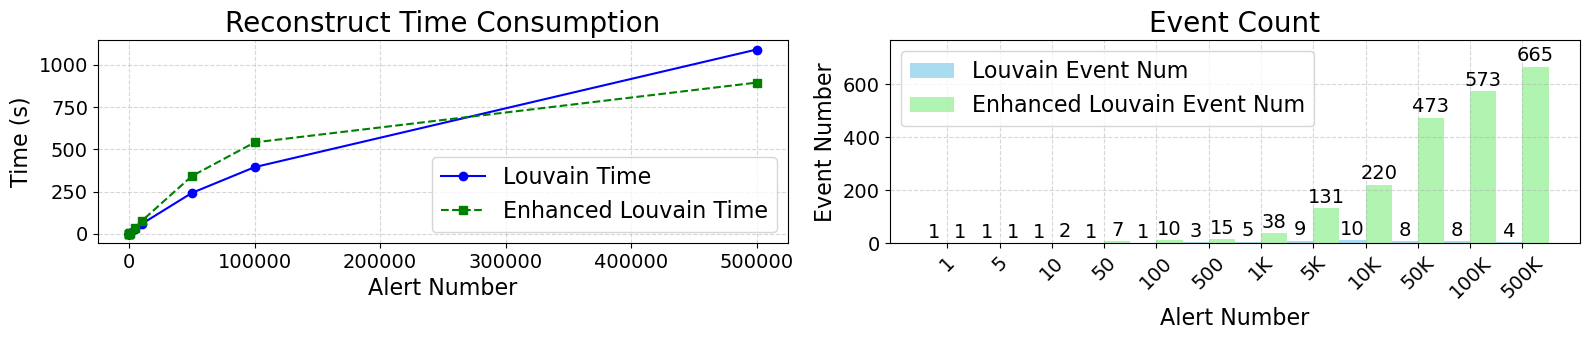

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
alert_num = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
event_louvain = [1, 1, 1, 1, 1, 3, 5, 9, 10, 8, 8, 4]
event_enhanced = [1, 1, 2, 7, 10, 15, 38, 131, 220, 473, 573, 665]
time_louvain = [0.05, 0.06, 0.09, 0.35, 0.81, 2.64, 6.43, 30.12, 58.97, 242.44, 394.95, 1090.50]
time_enhanced = [0.05, 0.06, 0.10, 0.34, 0.83, 3.66, 7.96, 35.92, 76.36, 342.01, 541.29, 894.92]

title_size = 20
label_front_size = 16
legend_front_size = 16 
x_y_front_size = 14
# 格式化标签
def format_alert_num(n):
    return f'{int(n/1000)}K' if n >= 1000 else str(n)
x_labels = list(map(format_alert_num, alert_num))
x_index = np.arange(len(alert_num))  # 用于右图

# 创建左右图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 3.5), sharey=False)

# ==== 左图：时间折线图（x轴为真实 alert 数量） ====
ax1.plot(alert_num, time_louvain, label='Louvain Time', linestyle='-', marker='o', color='blue')
ax1.plot(alert_num, time_enhanced, label='Enhanced Louvain Time', linestyle='--', marker='s', color='green')
ax1.set_xlabel('Alert Number', fontsize=label_front_size)
ax1.set_ylabel('Time (s)', fontsize=label_front_size)
ax1.set_title('Reconstruct Time Consumption', fontsize=title_size)
ax1.tick_params(axis='both', labelsize=x_y_front_size)

ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=legend_front_size)

# ==== 右图：事件数量柱状图（x轴为格式化标签） ====
bar_width = 0.50
ax2.bar(x_index - bar_width/2, event_louvain, width=bar_width, label='Louvain Event Num', color='skyblue', alpha=0.7)
ax2.bar(x_index + bar_width/2, event_enhanced, width=bar_width, label='Enhanced Louvain Event Num', color='lightgreen', alpha=0.7)
ax2.set_xticks(x_index)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_xlabel('Alert Number', fontsize=label_front_size)
ax2.set_ylabel('Event Number', fontsize=label_front_size)
ax2.set_title('Event Count', fontsize=title_size)
ax2.tick_params(axis='both', labelsize=x_y_front_size)

ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=legend_front_size)
# 设置y轴上限，避免文字超出
max_event = max(max(event_louvain), max(event_enhanced))
ax2.set_ylim(top=max_event * 1.15)

num_front_size = 14
# 添加数值标签
for i in range(len(x_index)):
    ax2.text(x_index[i] - bar_width/2, event_louvain[i] + 5, str(event_louvain[i]),
             ha='center', va='bottom', fontsize=num_front_size)
    ax2.text(x_index[i] + bar_width/2, event_enhanced[i] + 5, str(event_enhanced[i]),
             ha='center', va='bottom', fontsize=num_front_size)

plt.tight_layout()
plt.savefig("output_figures/enhanceLouvain_time_cost.pdf", format='pdf', bbox_inches='tight')

plt.show()

# model predection time cost

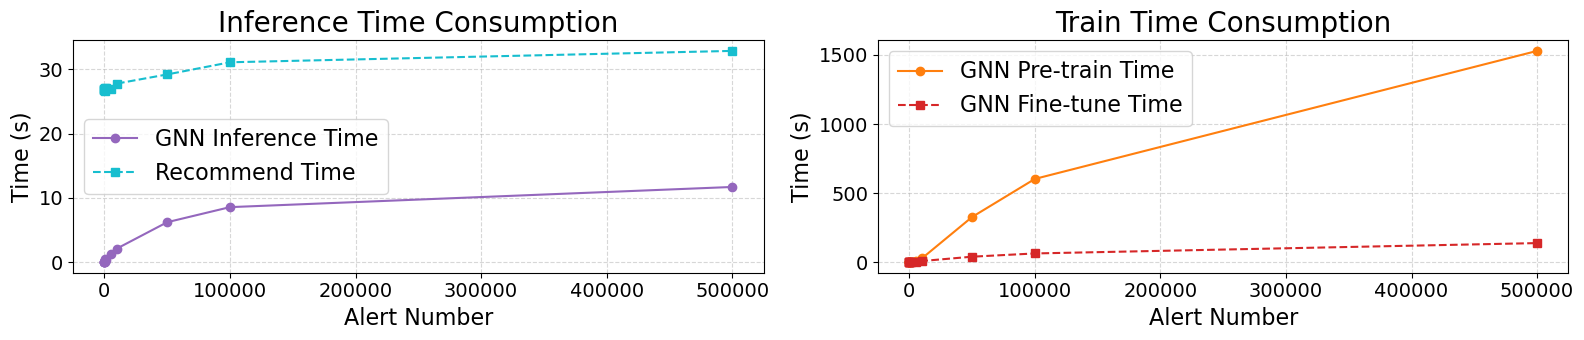

In [34]:
# 读入数据
import pandas as pd
# 读入excel
model_pred_df = pd.read_excel('../..//plot_res/input_data/runtime_cost/model_prediction_cost_time.xlsx')
alert_num = model_pred_df['alert_num'].to_list()
GNN_inference = model_pred_df['get_embedding_time'].to_list()
predict_time = model_pred_df['predict_time'].to_list()

# 读入训练数据的excel
train_df = pd.read_excel('../..//plot_res/input_data/runtime_cost/model_train_cost_time.xlsx')
pre_train_time = train_df['pre_train_time2'].to_list()
fine_tune_time = train_df['train_fine_tune_time'].to_list()

# 画图
import matplotlib.pyplot as plt
import numpy as np

title_size = 20
label_front_size = 16
legend_front_size = 16 
x_y_front_size = 14
# 格式化标签
def format_alert_num(n):
    return f'{int(n/1000)}K' if n >= 1000 else str(n)
x_labels = list(map(format_alert_num, alert_num))
x_index = np.arange(len(alert_num))  # 用于右图

# 创建左右图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 3.5), sharey=False)

# ==== 左图：时间折线图（x轴为真实 alert 数量） ====
ax1.plot(alert_num, GNN_inference, label='GNN Inference Time', linestyle='-', marker='o', color='#9467bd')
ax1.plot(alert_num, predict_time, label='Recommend Time', linestyle='--', marker='s', color='#17becf')
ax1.set_xlabel('Alert Number', fontsize=label_front_size)
ax1.set_ylabel('Time (s)', fontsize=label_front_size)
ax1.set_title('Inference Time Consumption', fontsize=title_size)
ax1.tick_params(axis='both', labelsize=x_y_front_size)

ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=legend_front_size)

# ==== 右图：事件数量柱状图（x轴为格式化标签） ====
ax2.plot(alert_num, pre_train_time, label='GNN Pre-train Time', linestyle='-', marker='o', color='#ff7f0e')
ax2.plot(alert_num, fine_tune_time, label='GNN Fine-tune Time', linestyle='--', marker='s', color='#d62728')
ax2.set_xlabel('Alert Number', fontsize=label_front_size)
ax2.set_ylabel('Time (s)', fontsize=label_front_size)
ax2.set_title('Train Time Consumption', fontsize=title_size)
ax2.tick_params(axis='both', labelsize=x_y_front_size)

ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=legend_front_size)


plt.tight_layout()
plt.savefig("output_figures/inference_train_time_cost_3.5.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 3. Robustness and Stability of the Model （加入噪声标签实验）

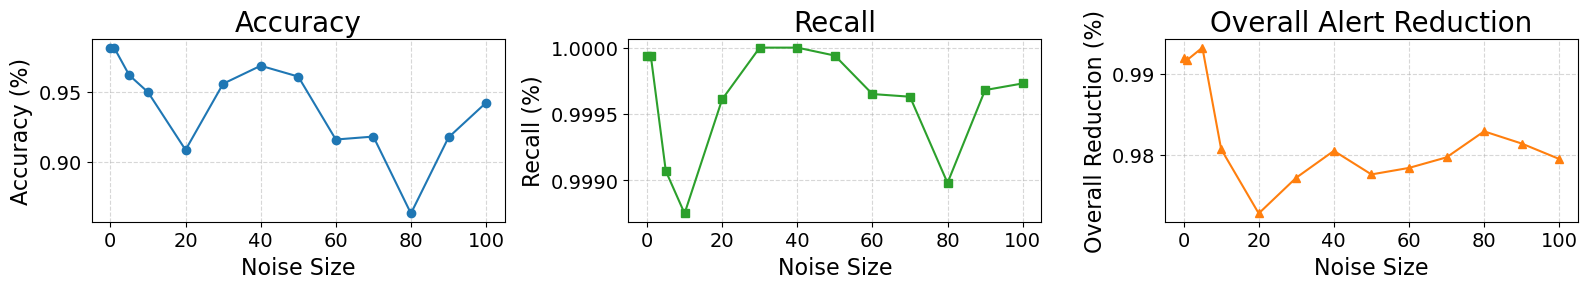

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_excel('../..//plot_res/input_data/noise_label/noise_label_data.xlsx')
noise_size = df['noise_size'].to_list()
accuracy = df['Accuracy'].to_list()
recall = df['Recall'].to_list()
f1_score = df['F1-Score'].to_list()
reduction = df['overall_reduction'].to_list()
# ========== 设置样式参数 ==========
title_size = 20
label_front_size = 16
legend_front_size = 16 
x_y_front_size = 14

# ========== 创建横排三个子图 ==========
fig, (ax1, ax2, ax4) = plt.subplots(1, 3, figsize=(16, 3))
# ===== Accuracy 曲线 =====
ax1.plot(noise_size, accuracy, marker='o', color='#1f77b4', label='Accuracy')
ax1.set_xlabel('Noise Size', fontsize=label_front_size)
ax1.set_ylabel('Accuracy (%)', fontsize=label_front_size)
ax1.set_title('Accuracy', fontsize=title_size)
ax1.tick_params(axis='both', labelsize=x_y_front_size)
ax1.grid(True, linestyle='--', alpha=0.5)

# ===== Recall 曲线 =====
ax2.plot(noise_size, recall, marker='s', color='#2ca02c', label='Recall')
ax2.set_xlabel('Noise Size', fontsize=label_front_size)
ax2.set_ylabel('Recall (%)', fontsize=label_front_size)
ax2.set_title('Recall', fontsize=title_size)
ax2.tick_params(axis='both', labelsize=x_y_front_size)
ax2.grid(True, linestyle='--', alpha=0.5)

# ===== F1-Score 曲线 =====
# ax3.plot(noise_size, f1_score, marker='D', color='#d62728', label='F1-Score')
# ax3.set_xlabel('Noise Size', fontsize=label_front_size)
# ax3.set_ylabel('F1-Score (%)', fontsize=label_front_size)
# ax3.set_title('F1-Score', fontsize=title_size)
# ax3.tick_params(axis='both', labelsize=x_y_front_size)
# ax3.grid(True, linestyle='--', alpha=0.5)

# ===== Overall Reduction 曲线 =====
ax4.plot(noise_size, reduction, marker='^', color='#ff7f0e', label='Reduction')
ax4.set_xlabel('Noise Size', fontsize=label_front_size)
ax4.set_ylabel('Overall Reduction (%)', fontsize=label_front_size)
ax4.set_title('Overall Alert Reduction', fontsize=title_size)
ax4.tick_params(axis='both', labelsize=x_y_front_size)
ax4.grid(True, linestyle='--', alpha=0.5)

# ========== 自动排版 & 保存 ==========
plt.tight_layout()
#plt.savefig("output_figures/noise_label_metrics.svg", format='svg', bbox_inches='tight')
plt.show()

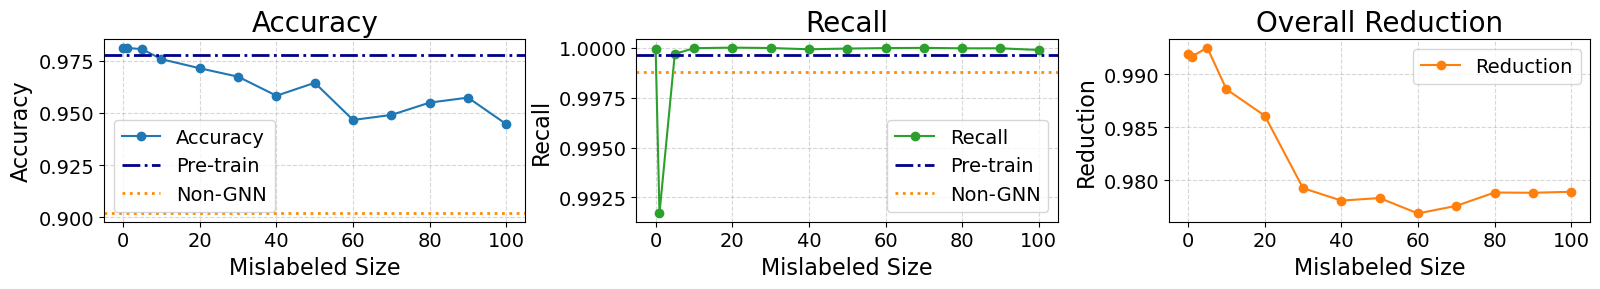

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
df = pd.read_excel('../..//plot_res/input_data/noise_label/noise_label_average_data.xlsx')
noise_size = df['noise_size'].to_list()
accuracy = df['Average_Acc'].to_list()
recall = df['Average_Recall'].to_list()
reduction = df['Average_Reduction'].to_list()

# === 参考线的真实数值 ===
acc_pretrain = 0.97775
acc_nongnn = 0.90181

recall_pretrain = 0.99962
recall_nongnn = 0.99880

reduction_pretrain = 0.9943
reduction_nongnn = 0.9978

# === 样式参数 ===
title_size = 20
label_front_size = 16
legend_front_size = 14
x_y_front_size = 14

# === 创建横排子图 ===
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 3))

# ===== Accuracy 图 =====
ax1.plot(noise_size, accuracy, marker='o', color='#1f77b4', label='Accuracy', linestyle='-')  # 主曲线
ax1.axhline(y=acc_pretrain, color='#00008B',  linestyle='-.', linewidth=2.0, label='Pre-train')  # 深蓝
ax1.axhline(y=acc_nongnn, color='#FF8C00', linestyle=':', linewidth=2.0, label='Non-GNN')       # 暗橙

# ax1.annotate(f'{accuracy[0]:.4f}',
#              xy=(noise_size[0], accuracy[0]),
#              xytext=(noise_size[0]+1, accuracy[0]-0.02),
#              fontsize=12, color='#1f77b4',
#              arrowprops=dict(arrowstyle='->', color='#1f77b4'))

ax1.set_xlabel('Mislabeled Size', fontsize=label_front_size)
ax1.set_ylabel('Accuracy', fontsize=label_front_size)
ax1.set_title('Accuracy', fontsize=title_size)
ax1.tick_params(axis='both', labelsize=x_y_front_size)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=legend_front_size)

# ===== Recall 图 =====
ax2.plot(noise_size, recall, marker='o', color='#2ca02c', label='Recall', linestyle='-')
ax2.axhline(y=recall_pretrain, color='#00008B',  linestyle='-.', linewidth=2.0, label='Pre-train')
ax2.axhline(y=recall_nongnn, color='#FF8C00',  linestyle=':', linewidth=2.0, label='Non-GNN')
# ax2.annotate(f'{recall[0]:.4f}', xy=(noise_size[0], recall[0]), xytext=(noise_size[0], recall[0]+0.001),
#              fontsize=12, color='#2ca02c')
ax2.set_xlabel('Mislabeled Size', fontsize=label_front_size)
ax2.set_ylabel('Recall', fontsize=label_front_size)
ax2.set_title('Recall', fontsize=title_size)
ax2.tick_params(axis='both', labelsize=x_y_front_size)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=legend_front_size)

# ===== Overall Reduction 图 =====
ax3.plot(noise_size, reduction, marker='o', color='#ff7f0e', label='Reduction', linestyle='-')# ax3.axhline(y=reduction_pretrain, color='#9467bd', linestyle='--', label='Pre-train')
# ax3.axhline(y=reduction_nongnn, color='#8c564b', linestyle='--', label='Non-GNN')
# ax3.annotate(f'{reduction[0]:.4f}', xy=(noise_size[0], reduction[0]), xytext=(noise_size[0], reduction[0]+0.002),
#              fontsize=12, color='#ff7f0e')
ax3.set_xlabel('Mislabeled Size', fontsize=label_front_size)
ax3.set_ylabel('Reduction', fontsize=label_front_size)
ax3.set_title('Overall Reduction', fontsize=title_size)
ax3.tick_params(axis='both', labelsize=x_y_front_size)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(fontsize=legend_front_size)

# === 自动排版 & 显示 ===
plt.tight_layout()
plt.savefig("output_figures/noise_label.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("output_figures/noise_label.png", format='png', bbox_inches='tight')

plt.show()


# bad pattern cluster识别率

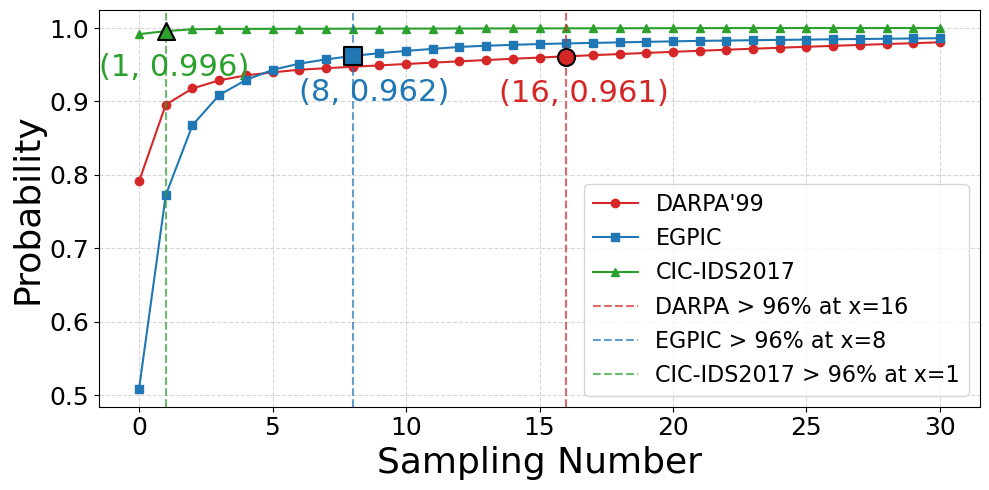

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Data
sampling_numbers = np.arange(31)
darpa_prob = [0.791304347826087, 0.8956521739130435, 0.9177274415339725, 0.9287650753444369, 0.935587774933074, 0.9395783697296378, 0.9432424030651418, 0.9452964147210348, 0.9472653336613398, 0.9491797327167302, 0.9510501432663567, 0.9528795748976031, 0.9546688810865541, 0.9564185478888206, 0.9581290518322724, 0.9598008601074536, 0.9614344307543188, 0.9630302128453593, 0.9645886466651896, 0.9661101638866589, 0.9675951877435567, 0.9690441331999752, 0.9704574071163958, 0.9718354084125603, 0.9731785282271894, 0.9744871500746117, 0.9757616499983609, 0.9770023967218019, 0.9782097517958441, 0.9793840697437977, 0.9805256982034318]  # DARPA'99 的概率数据（假设为随机值）
egpic_prob = [0.5090252707581226, 0.7725631768953068, 0.8676748832094707, 0.9087612581912983, 0.9292398198210812, 0.9430781404207419, 0.951496866095334, 0.9573237322626381, 0.9619873401893889, 0.9657821483226263, 0.9688279547229575, 0.971635233784715, 0.9742910480894208, 0.9759086769465624, 0.9771247700718617, 0.9782262091743672, 0.9790144003614595, 0.979766543315289, 0.9804879902773728, 0.9811831365448842, 0.9818555282104453, 0.9825079480697076, 0.9829705725199643, 0.983416751735883, 0.9838477242655601, 0.9842645524586252, 0.9846681393883977, 0.9850592397218547, 0.985438467043802, 0.9858063001168489, 0.9861630882239735]  # EGPIC 的概率数据（假设为随机值）
cic_prob = [0.9916550764951322, 0.9958275382475661, 0.9982665134748342, 0.998790590796396, 0.9988510612565762, 0.9989115317167564, 0.9989720021769366, 0.9990324726371168, 0.999092943097297, 0.9991534135574772, 0.9992138840176574, 0.9992743544778376, 0.9993348249380177, 0.9993952953981979, 0.9994557658583781, 0.9995162363185583, 0.9995767067787386, 0.9996371772389188, 0.999697647699099, 0.9997581181592792, 0.9998185886194594, 0.9998790590796396, 0.9999395295398198, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# Plot setup
plt.figure(figsize=(10, 5))
font_label_size = 26
point_text_size = 22

# Draw lines (Tableau 10 colors: red, blue, green)
plt.plot(sampling_numbers, darpa_prob, marker='o', color='#d62728', label="DARPA'99")
plt.plot(sampling_numbers, egpic_prob, marker='s', color='#1f77b4', label="EGPIC")
plt.plot(sampling_numbers, cic_prob, marker='^', color='#2ca02c', label="CIC-IDS2017")

# Axis labels in English
plt.xlabel("Sampling Number", fontsize=font_label_size)
plt.ylabel("Probability", fontsize=font_label_size)

# Annotations for EGPIC and DARPA thresholds
plt.axvline(x=16, linestyle='--', color='#d62728', alpha=0.7, label="DARPA > 96% at x=16")
darpa_y = round(darpa_prob[16], 3)
plt.scatter(16, darpa_y, color='#d62728', edgecolors='black', s=150, marker='o', linewidths=1.5, zorder=5)
plt.text(13.5, darpa_y - 0.03, f'({16}, {darpa_y})', fontsize=point_text_size, color='#d62728',
         verticalalignment='top', horizontalalignment='left')

# --- 修改 2: 调整 EGPIC 的标注位置（向下） ---
plt.axvline(x=8, linestyle='--', color='#1f77b4', alpha=0.7, label="EGPIC > 96% at x=8")
egpic_y = round(egpic_prob[8], 3)
# EGPIC: highlight point at x=8
plt.scatter(8, egpic_y, color='#1f77b4', edgecolors='black', s=150,  marker='s',linewidths=1.5, zorder=5)
plt.text(6, egpic_y - 0.03, f'({8}, {egpic_y})', fontsize=point_text_size, color='#1f77b4',
         verticalalignment='top', horizontalalignment='left')


# --- 修改 1: 添加 CIC-IDS2017 阈值标注 ---
plt.axvline(x=1, linestyle='--', color='#2ca02c', alpha=0.7, label="CIC-IDS2017 > 96% at x=1")
cic_y = round(cic_prob[1], 3)
plt.scatter(1, cic_y, color='#2ca02c', edgecolors='black', s=150, marker='^',  linewidths=1.5, zorder=5)
plt.text(-1.5, cic_y - 0.03, f'({1}, {cic_y})', fontsize=point_text_size, color='#2ca02c',
         verticalalignment='top', horizontalalignment='left')
# Legend & layout
plt.legend(fontsize=font_label_size - 10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save and show
plt.savefig("output_figures/sample_prob.pdf", format='pdf', bbox_inches='tight')
plt.show()


# 消融实验

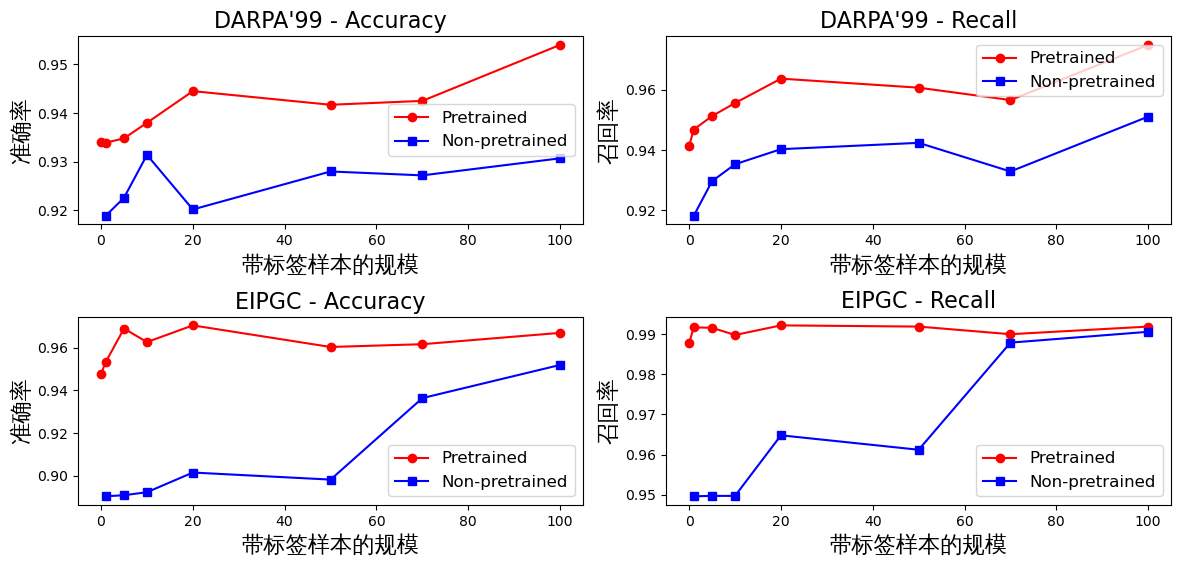

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
import pandas as pd
# 示例数据
train_data_size = [0, 1, 5, 10, 20, 50, 70, 100]
# pretrained_acc_darpa = [0.9298, 0.9236, 0.9297, 0.9358, 0.9614, 0.945, 0.9551, 0.9796]
# unpretrained_acc_darpa = [0.9348, 0.9264, 0.9186, 0.9262, 0.9192, 0.9149, 0.933, 0.9213]
# pretrained_recall_darpa = [0.9533, 0.9575, 0.9598, 0.9607, 0.9639, 0.9640, 0.9594, 0.9739]
# unpretrained_recall_darpa = [0.7318, 0.9453, 0.9289, 0.9034, 0.9590, 0.9233, 0.8897, 0.9721]
darpa_data = pd.read_excel("../..//plot_res/input_data/little_sample_learning/DARPA-1999.xlsx")
pretrained_acc_darpa = darpa_data['pretrain_acc'].to_list()
unpretrained_acc_darpa = darpa_data['no_pretrain_acc'].to_list()
pretrained_recall_darpa = darpa_data['pretrain_recall'].to_list()
unpretrained_recall_darpa = darpa_data['no_pretrain_recall'].to_list()

# pretrained_acc_EIPGC = [0.9477, 0.9532, 0.9689, 0.9626, 0.9704, 0.9603, 0.9616, 0.9669]
# unpretrained_acc_EIPGC = [0.8984, 0.8905, 0.891, 0.8924, 0.9016, 0.8983, 0.9364, 0.9519]
# pretrained_recall_EIPGC = [0.9878, 0.9917, 0.9916, 0.9898, 0.9922, 0.9919, 0.99, 0.9919]
# unpretrained_recall_EIPGC = [0.9641, 0.9496, 0.9497, 0.9497, 0.9648, 0.9612, 0.9879, 0.9906]

pretrained_acc_EIPGC = [0.9477, 0.9532, 0.9689, 0.9626, 0.9704, 0.9603, 0.9616, 0.9669]
unpretrained_acc_EIPGC = [np.nan, 0.8905, 0.891, 0.8924, 0.9016, 0.8983, 0.9364, 0.9519]
pretrained_recall_EIPGC = [0.9878, 0.9917, 0.9916, 0.9898, 0.9922, 0.9919, 0.99, 0.9919]
unpretrained_recall_EIPGC = [np.nan, 0.9496, 0.9497, 0.9497, 0.9648, 0.9612, 0.9879, 0.9906]


vertical_line_x = train_data_size[4]  # 第二个数据点，对应 20%

# 创建 2x2 子图
fig, axes = plt.subplots(2, 2, figsize=(12,6))

# 通用字体大小
label_fontsize = 16
legend_fontsize = 12
title_fontsize = 16

# 设置支持中文的字体
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 你可以根据你的系统调整字体路径
font_prop = font_manager.FontProperties(fname=font_path)

# 绘制每个子图
# DARPA ACC
axes[0, 0].plot(train_data_size, pretrained_acc_darpa, color='red', marker='o', label='Pretrained')
axes[0, 0].plot(train_data_size, unpretrained_acc_darpa, color='blue', marker='s', label='Non-pretrained')
axes[0, 0].set_title("DARPA'99 - Accuracy", fontsize=title_fontsize)
axes[0, 0].set_xlabel("带标签样本的规模", fontsize=label_fontsize, fontproperties=font_prop)
axes[0, 0].set_ylabel("准确率", fontsize=label_fontsize, fontproperties=font_prop)
axes[0, 0].legend(fontsize=legend_fontsize)

# DARPA Recall
axes[0, 1].plot(train_data_size, pretrained_recall_darpa, color='red', marker='o', label='Pretrained')
axes[0, 1].plot(train_data_size, unpretrained_recall_darpa, color='blue', marker='s', label='Non-pretrained')
# fontproperties与fontsize参数冲突，无法更改字体大小
#axes[0, 1].set_title("DARPA'99 - Accuracy", fontsize=title_fontsize, fontproperties=font_prop)
axes[0, 1].set_title("DARPA'99 - Recall", fontsize=title_fontsize)
axes[0, 1].set_xlabel("带标签样本的规模", fontsize=label_fontsize, fontproperties=font_prop)
axes[0, 1].set_ylabel("召回率", fontsize=label_fontsize, fontproperties=font_prop)
axes[0, 1].legend(fontsize=legend_fontsize)

# EIPGC ACC
axes[1, 0].plot(train_data_size, pretrained_acc_EIPGC, color='red', marker='o', label='Pretrained')
axes[1, 0].plot(train_data_size, unpretrained_acc_EIPGC, color='blue', marker='s', label='Non-pretrained')
axes[1, 0].set_title("EIPGC - Accuracy", fontsize=title_fontsize)
axes[1, 0].set_xlabel("带标签样本的规模", fontsize=label_fontsize, fontproperties=font_prop)
axes[1, 0].set_ylabel("准确率", fontsize=label_fontsize, fontproperties=font_prop)
axes[1, 0].legend(fontsize=legend_fontsize)

# EIPGC Recall
axes[1, 1].plot(train_data_size, pretrained_recall_EIPGC, color='red', marker='o', label='Pretrained')
axes[1, 1].plot(train_data_size, unpretrained_recall_EIPGC, color='blue', marker='s', label='Non-pretrained')
axes[1, 1].set_title("EIPGC - Recall", fontsize=title_fontsize)
axes[1, 1].set_xlabel("带标签样本的规模", fontsize=label_fontsize, fontproperties=font_prop)
axes[1, 1].set_ylabel("召回率", fontsize=label_fontsize, fontproperties=font_prop)
axes[1, 1].legend(fontsize=legend_fontsize)
# 调整布局，增加子图之间的垂直和水平间距
plt.subplots_adjust(hspace=2, wspace=0.3)
# 调整布局并显示
plt.tight_layout(rect=[0, 0, 1, 0.96])

#plt.savefig('trian_data_size.svg', format='svg')


plt.show()

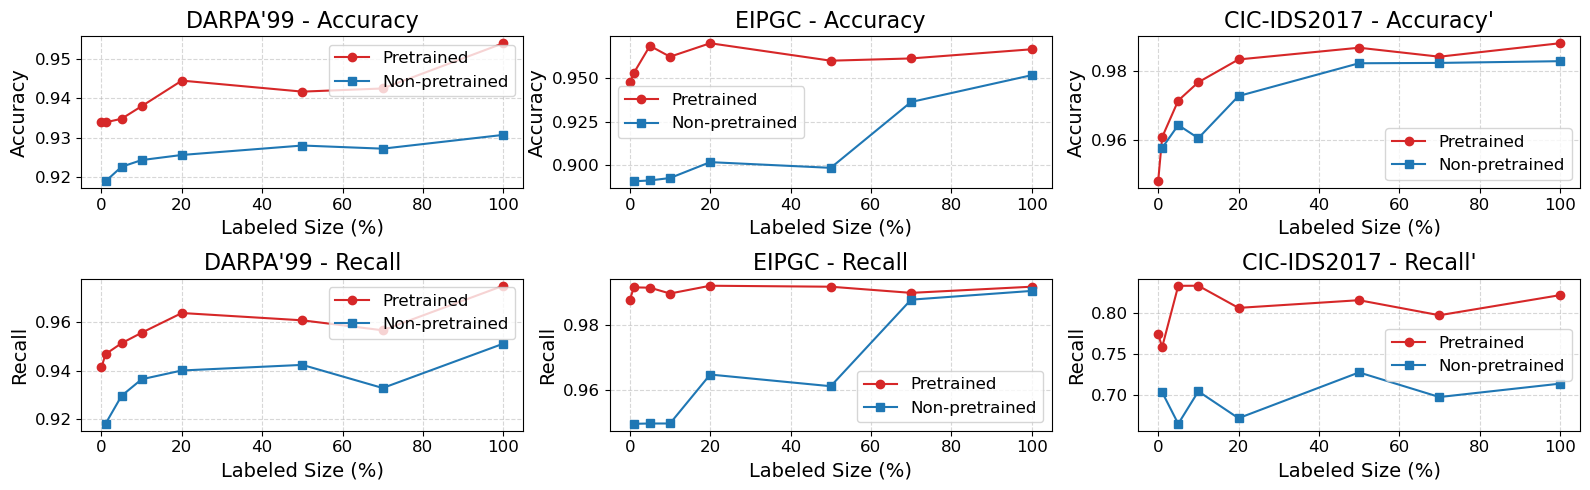

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === 读取数据 ===
darpa_data = pd.read_excel("../..//plot_res/input_data/little_sample_learning/DARPA-1999.xlsx")
cic_ids2017_data = pd.read_excel("../..//plot_res/input_data/little_sample_learning/CIC-IDS2017.xlsx")

train_data_size = [0, 1, 5, 10, 20, 50, 70, 100]

# === 提取 DARPA 数据 ===
pretrained_acc_darpa = darpa_data['pretrain_acc'].to_list()
unpretrained_acc_darpa = darpa_data['no_pretrain_acc'].to_list()
pretrained_recall_darpa = darpa_data['pretrain_recall'].to_list()
unpretrained_recall_darpa = darpa_data['no_pretrain_recall'].to_list()

# === 提取 EIPGC 数据（手动定义） ===
pretrained_acc_EIPGC = [0.9477, 0.9532, 0.9689, 0.9626, 0.9704, 0.9603, 0.9616, 0.9669]
unpretrained_acc_EIPGC = [np.nan, 0.8905, 0.891, 0.8924, 0.9016, 0.8983, 0.9364, 0.9519]
pretrained_recall_EIPGC = [0.9878, 0.9917, 0.9916, 0.9898, 0.9922, 0.9919, 0.99, 0.9919]
unpretrained_recall_EIPGC = [np.nan, 0.9496, 0.9497, 0.9497, 0.9648, 0.9612, 0.9879, 0.9906]

# === 提取 CIC-IDS2017 数据 ===
pretrained_acc_cic = cic_ids2017_data['pretrain_acc'].to_list()
unpretrained_acc_cic = cic_ids2017_data['no_pretrain_acc'].to_list()
pretrained_recall_cic = cic_ids2017_data['pretrain_recall'].to_list()
unpretrained_recall_cic = cic_ids2017_data['no_pretrain_recall'].to_list()

# === 样式参数 ===
title_size = 16
label_fontsize = 14
legend_fontsize = 12
tick_fontsize = 12

# === 创建两行三列子图 ===
fig, axes = plt.subplots(2, 3, figsize=(16, 5))  # 宽度放大适配三列

# === 配色 ===
colors = {
    'pre': '#d62728',  # 红
    'non': '#1f77b4'   # 蓝
}
markers = {
    'pre': 'o',
    'non': 's'
}

# === 绘图函数 ===
def plot_curve(ax, x, y1, y2, y_label, title, legend1='Pretrained', legend2='Non-pretrained'):
    ax.plot(x, y1, marker=markers['pre'], color=colors['pre'], label=legend1)
    ax.plot(x, y2, marker=markers['non'], color=colors['non'], label=legend2)
    ax.set_xlabel("Labeled Size (%)", fontsize=label_fontsize)
    ax.set_ylabel(y_label, fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_size)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=legend_fontsize)

# === 第一行：Accuracy ===
plot_curve(axes[0, 0], train_data_size, pretrained_acc_darpa, unpretrained_acc_darpa,
           "Accuracy", "DARPA'99 - Accuracy")
plot_curve(axes[0, 1], train_data_size, pretrained_acc_EIPGC, unpretrained_acc_EIPGC,
           "Accuracy", "EIPGC - Accuracy")
plot_curve(axes[0, 2], train_data_size, pretrained_acc_cic, unpretrained_acc_cic,
           "Accuracy", "CIC-IDS2017 - Accuracy'")

# === 第二行：Recall ===
plot_curve(axes[1, 0], train_data_size, pretrained_recall_darpa, unpretrained_recall_darpa,
           "Recall", "DARPA'99 - Recall")
plot_curve(axes[1, 1], train_data_size, pretrained_recall_EIPGC, unpretrained_recall_EIPGC,
           "Recall", "EIPGC - Recall")
plot_curve(axes[1, 2], train_data_size, pretrained_recall_cic, unpretrained_recall_cic,
           "Recall", "CIC-IDS2017 - Recall'")

# === 布局优化与保存 ===
plt.tight_layout()
plt.savefig("output_figures/little_sample_learning.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [3]:
unpretrained_acc_darpa

[nan, 0.9189, 0.9226, 0.9314, 0.9202, 0.928, 0.9272, 0.9256]

RQ2：模型是否能在少量带标签样本下依旧有效，不依赖于大量标签样本学习？（Can our approach remain effective with a few labeled samples, without relying on a large amount of labeled samples？）

三个结论回答RQ2：
- **Zero-Shot**：预训练模型具备零样本学习能力。As shown in Fig.，在train data size为0时，即没有任何带标签样本参与训练的情况下，预训练模型在两个数据集的准确率和召回率均达到了90%以上，远高于随机初始化模型，甚至有接近100% train data size的无预训练模型的表现。


- **Few-Shot**：预训练模型能够从少量标签样本中学习并快速逼近能力上限，而未预训练的模型则无此性质。As shown in Fig.，在train data size小于等10%区间内，因为训练数据十分有限，未预训练模型无法学习到有用信息，除了在DARAP'99数据集上的召回有明显提升外（随后在5%，10%下降），其他情况均出现了下滑。而经过预训练后的模型能从少量标签数据中学习，在DARPA'99数据集上10%的带标签数据提升了1.22%和0.74%的准确率和召回率，在EPIGC上分别提升了1.49%和0.20%的准确率和召回率。随后，20%的带标签数据使预训练模型在EPIGC数据集达到了能力上限，在DARAP'99数据集上与最优结果的准确率和召回率分别仅相差1.82%和1.00%。


- **微调策略的有效性**：微调能够提升预训练模型的能力上限，微调后模型的准确率和召回率在DARPA'99数据集上分别提升了4.98%和2.06%，在EPIGC上分别提升了2.27%和0.44%。

In [ ]:
import matplotlib.pyplot as plt

import numpy as np

# 示例数据
sampling_numbers = np.arange(31)  # 采样数从0到31
darpa_prob = [0.791304347826087, 0.8956521739130435, 0.9177274415339725, 0.9287650753444369, 0.935587774933074, 0.9395783697296378, 0.9432424030651418, 0.9452964147210348, 0.9472653336613398, 0.9491797327167302, 0.9510501432663567, 0.9528795748976031, 0.9546688810865541, 0.9564185478888206, 0.9581290518322724, 0.9598008601074536, 0.9614344307543188, 0.9630302128453593, 0.9645886466651896, 0.9661101638866589, 0.9675951877435567, 0.9690441331999752, 0.9704574071163958, 0.9718354084125603, 0.9731785282271894, 0.9744871500746117, 0.9757616499983609, 0.9770023967218019, 0.9782097517958441, 0.9793840697437977, 0.9805256982034318]  # DARPA'99 的概率数据（假设为随机值）
egpic_prob = [0.5090252707581226, 0.7725631768953068, 0.8676748832094707, 0.9087612581912983, 0.9292398198210812, 0.9430781404207419, 0.951496866095334, 0.9573237322626381, 0.9619873401893889, 0.9657821483226263, 0.9688279547229575, 0.971635233784715, 0.9742910480894208, 0.9759086769465624, 0.9771247700718617, 0.9782262091743672, 0.9790144003614595, 0.979766543315289, 0.9804879902773728, 0.9811831365448842, 0.9818555282104453, 0.9825079480697076, 0.9829705725199643, 0.983416751735883, 0.9838477242655601, 0.9842645524586252, 0.9846681393883977, 0.9850592397218547, 0.985438467043802, 0.9858063001168489, 0.9861630882239735]  # EGPIC 的概率数据（假设为随机值）
# 设置中文字体（选择你系统支持的字体）
# 设置支持中文的字体
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 你可以根据你的系统调整字体路径
font_prop = font_manager.FontProperties(fname=font_path)
# 创建单图
plt.figure(figsize=(10, 5))

font_label_size = 20
point_text_size = 18
# 绘制折线
plt.plot(sampling_numbers, darpa_prob, marker='o', color='red', label="DARPA'99")
plt.plot(sampling_numbers, egpic_prob, marker='s', color='blue', label="EGPIC")

# 设置标题和标签
plt.xlabel("采样数量", fontsize=font_label_size, fontproperties=font_prop)
plt.ylabel("识别不良集群的概率", fontsize=font_label_size, fontproperties=font_prop)

plt.axvline(x=8, linestyle='--', label=f'EIPGC > 96% at x={8}')
EIPGC_least = round(egpic_prob[8],3)
plt.scatter(8, EIPGC_least, zorder=5)
plt.text(8, EIPGC_least, f'({8}, {EIPGC_least})', fontsize=point_text_size, verticalalignment='bottom', horizontalalignment='right')


plt.axvline(x=16, linestyle='--', label=f'DARPA > 96% at x={16}')
DARPA_least = round(darpa_prob[16],3)
plt.scatter(16, DARPA_least, zorder=5)
plt.text(16, DARPA_least-0.02, f'({16}, {DARPA_least})', fontsize=point_text_size, verticalalignment='top', horizontalalignment='left')
# 添加图例
plt.legend(fontsize=font_label_size-7)
# 保存为 .svg 格式
plt.savefig('plot_output.svg', format='svg')
# 显示图表
plt.tight_layout()
plt.show()

In [ ]:

import matplotlib.pyplot as plt

import numpy as np

# 示例数据
sampling_numbers = np.arange(31)  # 采样数从0到31
darpa_prob = [0.7851239669421488, 0.8925619834710744, 0.9131007554769677, 0.9233701414799143, 0.9304836304977234, 0.935330465788804, 0.9399798516030833, 0.9430559217459655, 0.9459375559081563, 0.9486261857863731, 0.9511232068189963, 0.9534299788197355, 0.9556980895578119, 0.957928829450767, 0.9601234551312422, 0.9616928712750015, 0.963228587511189, 0.9647317626935774, 0.9662035242542975, 0.9676449687794877, 0.9690571625791178, 0.9704411422511032, 0.9717979152398271, 0.9731284603891804, 0.9744337284902356, 0.9757146428236582, 0.976972099696969, 0.9782069689767598, 0.979420094615968, 0.9803171357902437, 0.9811940455738534]
egpic_prob = [0.6339285714285714, 0.8244047619047619, 0.8979169624579016, 0.932644102111761, 0.9488582553164346, 0.959355864930215, 0.9661326596808597, 0.971352178535422, 0.9752873928925122, 0.9785237851511001, 0.9808078464429401, 0.9822824318857848, 0.9836070107036348, 0.9845432241872962, 0.9853864402509356, 0.9861453932367198, 0.9868283560759878, 0.9874679418765528, 0.9878964307200875, 0.9882957813334591, 0.988672421004696, 0.9890297049175991, 0.9893705268451414, 0.989697319149468, 0.9900107083706146, 0.9903111957406093, 0.9905991571834736, 0.990884000824379, 0.9911658519713327, 0.9914447106243345, 0.9917205767833845]
# 设置中文字体（选择你系统支持的字体）
# 设置支持中文的字体
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 你可以根据你的系统调整字体路径
font_prop = font_manager.FontProperties(fname=font_path)
# 创建单图
plt.figure(figsize=(10, 5))

font_label_size = 20
point_text_size = 18
# 绘制折线
plt.plot(sampling_numbers, darpa_prob, marker='o', color='red', label="DARPA'99")
plt.plot(sampling_numbers, egpic_prob, marker='s', color='blue', label="EGPIC")

# 设置标题和标签
plt.xlabel("采样数量", fontsize=font_label_size, fontproperties=font_prop)
plt.ylabel("识别不良集群的概率", fontsize=font_label_size, fontproperties=font_prop)

plt.axvline(x=6, linestyle='--', label=f'EIPGC > 96% at x={6}')
EIPGC_least = round(egpic_prob[6],3)
plt.scatter(6, EIPGC_least, zorder=5)
plt.text(6, EIPGC_least, f'({6}, {EIPGC_least})', fontsize=point_text_size, verticalalignment='bottom', horizontalalignment='right')


plt.axvline(x=14, linestyle='--', label=f'DARPA > 96% at x={14}')
DARPA_least = round(darpa_prob[14],3)
plt.scatter(14, DARPA_least, zorder=5)
plt.text(14, DARPA_least-0.02, f'({14}, {DARPA_least})', fontsize=point_text_size, verticalalignment='top', horizontalalignment='left')
# 添加图例
plt.legend(fontsize=font_label_size-7)
# 保存为 .svg 格式
plt.savefig('bad_pro.svg', format='svg')
# 显示图表
plt.tight_layout()
plt.show()

# 最高风险等级成功识别概率

In [ ]:

import matplotlib.pyplot as plt

import numpy as np

# 示例数据
sampling_numbers = np.arange(31)  # 采样数从0到31
darpa_prob = [0.8925619834710744, 0.9057900137871523, 0.9160593997900989, 0.9233718042373418, 0.9304836706603354, 0.9353304664594064, 0.9399798516107579, 0.9430559217461114, 0.9459375559081585, 0.9486261857863731, 0.9511232068189963, 0.9534299788197355, 0.9556980895578119, 0.957928829450767, 0.9601234551312422, 0.9616928712750015, 0.963228587511189, 0.9647317626935774, 0.9662035242542975, 0.9676449687794877, 0.9690571625791178, 0.9704411422511032, 0.9717979152398271, 0.9731284603891804, 0.9744337284902356, 0.9757146428236582, 0.976972099696969, 0.9782069689767598, 0.979420094615968, 0.9803171357902437, 0.9811940455738534]
egpic_prob = [0.8244047619047619, 0.908579838787585, 0.9439108017015175, 0.9635172471810132, 0.9734522498022163, 0.9796629754348247, 0.9841145503474791, 0.9877800088102926, 0.9903611375903365, 0.9923682662010729, 0.9938742823974409, 0.9949846813066215, 0.996057021897493, 0.9968486542533586, 0.9973835610637877, 0.9978951231923818, 0.9983873223629771, 0.99867766698382, 0.9987801578338421, 0.9988724624324076, 0.998956716860042, 0.999034595786443, 0.999107312470481, 0.9991756187601982, 0.9992401411956303, 0.9993013810088054, 0.9993597141237447, 0.9994153911564626, 0.999468537414966, 0.999519152899255, 0.9995672376093294]
# 设置中文字体（选择你系统支持的字体）
# 设置支持中文的字体
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 你可以根据你的系统调整字体路径
font_prop = font_manager.FontProperties(fname=font_path)
# 创建单图
plt.figure(figsize=(10, 5))

font_label_size = 20
point_text_size = 18
# 绘制折线
plt.plot(sampling_numbers, darpa_prob, marker='o', color='red', label="DARPA'99")
plt.plot(sampling_numbers, egpic_prob, marker='s', color='blue', label="EGPIC")

# 设置标题和标签
plt.xlabel("采样数量", fontsize=font_label_size, fontproperties=font_prop)
plt.ylabel("识别最高风险等级的概率", fontsize=font_label_size, fontproperties=font_prop)

plt.axvline(x=6, linestyle='--', label=f'EIPGC = 98.41% at x={6}')
EIPGC_least = round(egpic_prob[6],3)
plt.scatter(6, EIPGC_least, zorder=5)
plt.text(6, EIPGC_least, f'({6}, {EIPGC_least})', fontsize=point_text_size, verticalalignment='bottom', horizontalalignment='right')


plt.axvline(x=14, linestyle='--', label=f'DARPA = 96.01% at x={14}')
DARPA_least = round(darpa_prob[14],3)
plt.scatter(14, DARPA_least, zorder=5)
plt.text(14, DARPA_least-0.02, f'({14}, {DARPA_least})', fontsize=point_text_size, verticalalignment='top', horizontalalignment='left')
# 添加图例
plt.legend(fontsize=font_label_size-7)
# 保存为 .svg 格式
plt.savefig('highest_pro.svg', format='svg')
# 显示图表
plt.tight_layout()
plt.show()

# 时间参数T的讨论

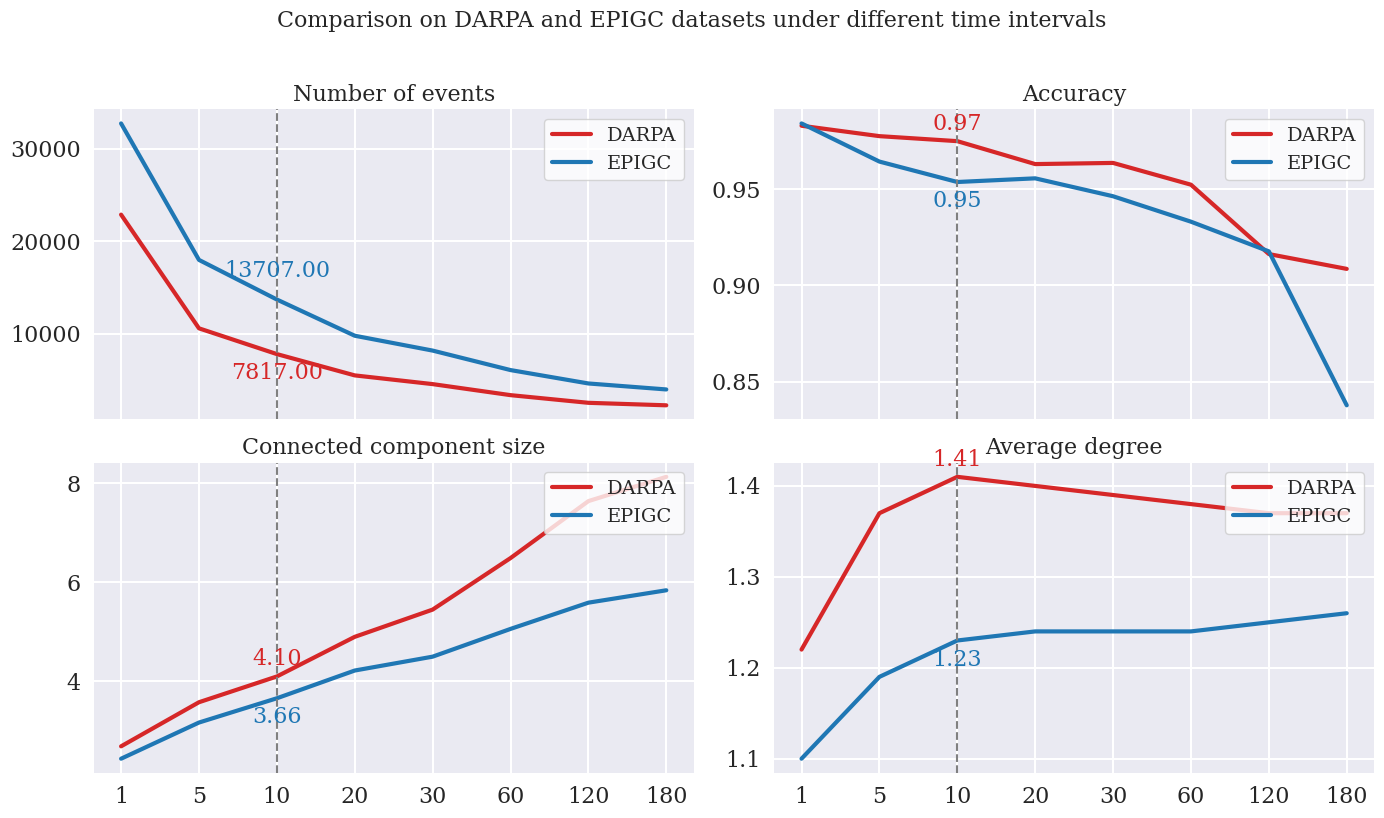

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white', font='serif')

# 将时间间隔作为字符串类别，等距展示
T = ['1', '5', '10', '20', '30', '60', '120', '180']

metrics = ['Number of events', 'Accuracy','Connected component size', 'Average degree']
darpa_data = {
    'Number of events':    [22869, 10597, 7817, 5518, 4577, 3386, 2558, 2289],
    'Connected component size':   [2.69, 3.58, 4.1, 4.9, 5.45, 6.49, 7.64, 8.13],
    'Average degree':      [1.22, 1.37, 1.41, 1.4, 1.39, 1.38, 1.37, 1.37],
    'Accuracy':    [0.9829, 0.9775, 0.9749, 0.963, 0.9636, 0.9523, 0.9163, 0.9086],
}
epigc_data = {
    'Number of events':    [32712, 17983, 13707, 9798, 8195, 6092, 4646, 4001],
    'Connected component size':   [2.44, 3.17, 3.66, 4.22, 4.5, 5.06, 5.59, 5.84],
    'Average degree':      [1.1, 1.19, 1.23, 1.24, 1.24, 1.24, 1.25, 1.26],
    'Accuracy':    [0.9841, 0.9643, 0.9537, 0.9556, 0.9463, 0.9331, 0.9177, 0.8378],
}

colors = {
    'DARPA': '#d62728',
    'EPIGC': '#1f77b4',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

highlight_index = T.index('10')  # 找出 '10' 的索引

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.set_facecolor('#EAEAF2')
    ax.yaxis.grid(True, color='white', linewidth=1.5)
    ax.xaxis.grid(True, color='white', linewidth=1.5)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.plot(T, darpa_data[metric], label='DARPA', color=colors['DARPA'], linewidth=3)
    ax.plot(T, epigc_data[metric], label='EPIGC', color=colors['EPIGC'], linewidth=3)

    # 高亮 10 分钟位置
    ax.axvline(x=T[highlight_index], color='gray', linestyle='--', linewidth=1.5)
    #ax.text(T[highlight_index], ax.get_ylim()[1], '10', color='black', fontsize=10, ha='center', va='bottom')

    # 获取并标注10分钟时刻的 Y 值
    y_darpa = darpa_data[metric][highlight_index]
    y_epigc = epigc_data[metric][highlight_index]
    if i==0:
        ax.annotate(f'{y_darpa:.2f}', xy=(T[highlight_index], y_darpa), xytext=(0, -18),
                    textcoords='offset points', ha='center', color=colors['DARPA'], fontsize=16)

        ax.annotate(f'{y_epigc:.2f}', xy=(T[highlight_index], y_epigc), xytext=(0, 16),
                    textcoords='offset points', ha='center', color=colors['EPIGC'], fontsize=16)
    else:
        ax.annotate(f'{y_darpa:.2f}', xy=(T[highlight_index], y_darpa), xytext=(0, 8),
                    textcoords='offset points', ha='center', color=colors['DARPA'], fontsize=16)

        ax.annotate(f'{y_epigc:.2f}', xy=(T[highlight_index], y_epigc), xytext=(0, -18),
                    textcoords='offset points', ha='center', color=colors['EPIGC'], fontsize=16)

    ax.set_title(metric, fontsize=16)
    ax.set_xticks(T)
    ax.tick_params(axis='both', labelsize=16)

    ax.legend(loc='upper right', fontsize=14)
plt.suptitle('Comparison on DARPA and EPIGC datasets under different time intervals', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('different_T_res.svg', format='svg')
plt.show()